# 04 — Baseline & Quick BO — Isolated Kernel Safe

**Purpose**  
Establish strong baselines and fast Bayesian warm-starts using the staged feature arrays, ensuring **single source of truth** and **no leakage** under orchestrated execution.

**Scope**
- Restore `CANON.json` (**must**) and staged arrays (**must**).
- Train and evaluate Logistic Regression and LightGBM baselines (**must**).
- Run **quick** Bayesian searches for LightGBM, XGBoost, and CatBoost (**should**).
- Persist artefacts: metrics CSV, curves, fitted models, and champion (**should**).

## Section 0.05 — Restore Canonical Config (Single Source)

**What this does**
- Loads `RANDOM_STATE`, `STAGE_ROOT`, `OUT_ROOT`, plus informational `DATA_PATH`, `TARGET_COL` from `CANON.json` produced by `01-Setup_Preflight`.

**Must**
- Provide a single source of truth across isolated kernels.

In [1]:

# ======================================================
# Section 0.05 — Restore Canonical Config (Single Source)
# ======================================================
print(">>> Section 0.05 — Restore Canonical Config (Single Source)")

import json
from pathlib import Path

candidates = [Path("CANON.json"), Path("staging") / "CANON.json"]
src = next((p for p in candidates if p.exists()), None)
assert src is not None, "[0.05] CANON.json not found. Run 01-Setup_Preflight (0.1) first."

cfg = json.loads(src.read_text(encoding="utf-8"))
from pathlib import Path as _Path
RANDOM_STATE = cfg["RANDOM_STATE"]
DATA_PATH    = _Path(cfg["DATA_PATH"])   # informational
TARGET_COL   = cfg["TARGET_COL"]         # informational
STAGE_ROOT   = _Path(cfg["STAGE_ROOT"])
OUT_ROOT     = _Path(cfg["OUT_ROOT"])

print(f"[0.05] Loaded CANON from {src}")
print(f"[0.05] STAGE_ROOT={STAGE_ROOT.resolve()} | OUT_ROOT={OUT_ROOT.resolve()}")


>>> Section 0.05 — Restore Canonical Config (Single Source)
[0.05] Loaded CANON from CANON.json
[0.05] STAGE_ROOT=/Users/max/Library/CloudStorage/OneDrive-Personal/Imperial Pro Cert in Machine Learning and Artificial Intelligence/IMP-PCMLAI-M25-final-project/BenignIDS_Notebooks_v3/staging | OUT_ROOT=/Users/max/Library/CloudStorage/OneDrive-Personal/Imperial Pro Cert in Machine Learning and Artificial Intelligence/IMP-PCMLAI-M25-final-project/BenignIDS_Notebooks_v3/out


# ======================================================
# Section 0.6 — Restore staged feature matrices (robust)
# ======================================================
**What this does**

- Restores `X_train/X_val/X_test` and `y_*` from `STAGE_ROOT/split_preproc`.
- Prefers **combined** structured+TF-IDF (`*_all.npz|.npy`), otherwise falls back to structured-only.
- Robust loader handles:
  - `.npz` (sparse CSR via `scipy.sparse.load_npz`)
  - `.npy` (dense)
  - legacy `.npy` wrapping a single `csr_matrix` in a 0-D object → unwrap `.item()`
  - `.joblib` (if present)
- Prints shapes/types to confirm CSR/Dense as expected.

**Inputs (must exist)**

- `STAGE_ROOT`, and `RANDOM_STATE` for reproducibility.

**Outputs**

- Global `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`.


In [2]:
# ======================================================
# Section 0.6 — Restore staged feature matrices (robust)
# ======================================================
print(">>> Section 0.6 — robust restore from STAGE_ROOT/split_preproc")

from pathlib import Path as _P
import numpy as _np
import joblib as _joblib
from scipy import sparse as _sp

assert 'STAGE_ROOT' in globals(), "[0.6] STAGE_ROOT not defined; run 01-Setup_Preflight first."
_split_dir = _P(STAGE_ROOT) / "split_preproc"
assert _split_dir.exists(), f"[0.6] Missing directory: {_split_dir}. Run 02-Feature_Engineering."

def _load_array(basepath: _P):
    """
    Load an array from basepath (no suffix). Priority:
      1) .npz (scipy.sparse CSR)
      2) .npy (dense or legacy 0-D object wrapping csr_matrix)
      3) .joblib
    """
    basepath = _P(basepath)
    p_npz = basepath.with_suffix(".npz")
    p_npy = basepath.with_suffix(".npy")
    p_jbl = basepath.with_suffix(".joblib")

    if p_npz.exists():
        from scipy.sparse import load_npz
        arr = load_npz(str(p_npz))
        return arr

    if p_npy.exists():
        obj = _np.load(p_npy, allow_pickle=True)
        # Legacy sparse case: a 0-D object array holding a CSR matrix
        if isinstance(obj, _np.ndarray) and obj.dtype == object and (obj.shape == () or obj.size == 1):
            obj = obj.item()
        return obj

    if p_jbl.exists():
        return _joblib.load(p_jbl)

    raise FileNotFoundError(f"Could not find .npz/.npy/.joblib for {basepath}")

def _as_2d(X):
    # Ensure 2D structure for estimators (CSR or ndarray)
    if _sp.issparse(X):
        return X.tocsr()
    X = _np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return X

# Prefer combined; fallback to structured-only
try:
    X_train = _load_array(_split_dir / "X_train_all")
    X_val   = _load_array(_split_dir / "X_val_all")
    X_test  = _load_array(_split_dir / "X_test_all")
    print("[0.6] restored combined structured + TF-IDF features")
except Exception as _e:
    print(f"[0.6] combined features unavailable → {_e} ; falling back to structured-only")
    X_train = _load_array(_split_dir / "X_train")
    X_val   = _load_array(_split_dir / "X_val")
    X_test  = _load_array(_split_dir / "X_test")

# Always coerce to estimator-friendly 2D
X_train = _as_2d(X_train)
X_val   = _as_2d(X_val)
X_test  = _as_2d(X_test)

# Labels
y_train = _np.load(_split_dir / "y_train.npy", allow_pickle=True).astype("int64")
y_val   = _np.load(_split_dir / "y_val.npy",   allow_pickle=True).astype("int64")
y_test  = _np.load(_split_dir / "y_test.npy",  allow_pickle=True).astype("int64")

print(f"[0.6] X_train: shape={getattr(X_train,'shape',None)}, type={type(X_train).__name__}, sparse={_sp.issparse(X_train)}")
print(f"[0.6] X_val:   shape={getattr(X_val,'shape',None)}, type={type(X_val).__name__}, sparse={_sp.issparse(X_val)}")
print(f"[0.6] X_test:  shape={getattr(X_test,'shape',None)}, type={type(X_test).__name__}, sparse={_sp.issparse(X_test)}")
print(f"[0.6] y shapes: train={y_train.shape}, val={y_val.shape}, test={y_test.shape}")
print(">>> Section 0.6: restore complete")


>>> Section 0.6 — robust restore from STAGE_ROOT/split_preproc


[0.6] combined features unavailable → File is not a zip file ; falling back to structured-only
[0.6] X_train: shape=(36000, 23), type=csr_matrix, sparse=True
[0.6] X_val:   shape=(12000, 23), type=csr_matrix, sparse=True
[0.6] X_test:  shape=(12000, 23), type=csr_matrix, sparse=True
[0.6] y shapes: train=(15545,), val=(3331,), test=(12000,)
>>> Section 0.6: restore complete


In [3]:
# ======================================================
# Section 4.0 — Payload Bootstrap (rebuild payload features in this kernel) [CHUNKED]
#   • Load vectorizer from staging/section_2/
#   • Recreate splits from DATA_PATH if needed
#   • Chunked fold (if needed) + chunked TF-IDF transform to build X_*_payload
# ======================================================
print(">>> Section 4.0: Payload Bootstrap [CHUNKED]")

from pathlib import Path
import os, json, numpy as np, pandas as pd, re, joblib, math, sys
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy import sparse as sp

# --- Config / paths ---
STAGE_ROOT   = Path(STAGE_ROOT) if 'STAGE_ROOT' in globals() else Path("staging")
OUT_ROOT     = Path(OUT_ROOT)   if 'OUT_ROOT'   in globals() else Path("out")
RANDOM_STATE = int(globals().get('RANDOM_STATE', 1337))
SEC2_DIR     = STAGE_ROOT / "section_2"
VEC_PATH     = SEC2_DIR / "vectorizer.joblib"
CHUNK_ROWS   = int(globals().get("PAYLOAD_CHUNK_ROWS", 50000))  # tune if needed

# --- Utilities ---
def _ensure_dataframe_splits():
    need_rebuild = False
    for nm in ["X_train","X_val","X_test","y_train","y_val","y_test"]:
        if nm not in globals():
            need_rebuild = True; break
        obj = globals()[nm]
        if nm.startswith("X_") and not isinstance(obj, pd.DataFrame):
            need_rebuild = True; break
    if need_rebuild:
        assert "DATA_PATH" in globals() and os.path.exists(DATA_PATH), \
            "Splits missing and DATA_PATH not available to rebuild."
        df = pd.read_csv(DATA_PATH)
        # Derive target: map attack categories (non-benign => 1)
        target_col = globals().get("TARGET_COL", "label")
        if target_col in df.columns and df[target_col].astype(str).str.lower().nunique() > 2:
            y = (df[target_col].astype(str).str.strip().str.lower() != "benign").astype(int)
        elif "attack_cat" in df.columns:
            y = (df["attack_cat"].astype(str).str.strip().str.lower() != "benign").astype(int)
        else:
            # numeric/bool fallback
            t = df[target_col] if target_col in df.columns else df["label"]
            if pd.api.types.is_bool_dtype(t):
                y = t.astype(int)
            else:
                u = set(pd.Series(t).dropna().unique().tolist())
                assert u.issubset({0,1}), f"Target not binary: {u}"
                y = t.astype(int)
        X = df.drop(columns=[c for c in df.columns if c == target_col or c == "label"], errors="ignore")
        X_train, X_hold, y_train, y_hold = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
        X_val, X_test, y_val, y_test     = train_test_split(X_hold, y_hold, test_size=0.5, random_state=RANDOM_STATE, stratify=y_hold)
        g = globals()
        g.update(dict(X_train=X_train, X_val=X_val, X_test=X_test, y_train=y_train, y_val=y_val, y_test=y_test))
        print(f"[4.0] Recreated splits from DATA_PATH. train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")

def _payload_cols(df: pd.DataFrame):
    pat = re.compile(r"^payload_byte_(\d+)$")
    cols = []
    for c in df.columns:
        m = pat.match(str(c))
        if m: cols.append((int(m.group(1)), c))
    cols.sort(key=lambda x: x[0])
    return [c for _, c in cols]

# Fast byte → hex token lookup
_HEX_TOK = np.array([f"{i:02X}" for i in range(256)], dtype=object)

def _fold_chunk_bytes_to_strings(df_chunk: pd.DataFrame, cols: list[str]) -> pd.Series:
    """Vectorized folding: map bytes to hex tokens and join with spaces per row."""
    # Coerce to uint16 to avoid negative/NaN issues, then clip
    arr = df_chunk[cols].to_numpy(copy=False)
    # Handle NaNs / non-numeric robustly
    if not np.issubdtype(arr.dtype, np.number):
        arr = pd.DataFrame(arr).apply(pd.to_numeric, errors="coerce").to_numpy()
    arr = np.nan_to_num(arr, nan=0.0, posinf=255.0, neginf=0.0).astype(np.int16)
    np.clip(arr, 0, 255, out=arr)
    tok = _HEX_TOK[arr]  # shape (rows, cols) of strings
    # Join tokens per row; use Python join in a comprehension (fast enough per CHUNK_ROWS)
    return pd.Series((" ".join(row) for row in tok), index=df_chunk.index, dtype="object")

def _series_payload(df: pd.DataFrame) -> tuple[pd.Series, str]:
    """Return (series_of_strings, source) without adding it back to DF."""
    if "payload" in df.columns:
        s = df["payload"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
        s = s.mask(s == "", "00")
        return s, "payload"
    cols = _payload_cols(df)
    assert cols, "No payload column nor payload_byte_* columns available"
    # Will fold by chunks later; here we only indicate that we're on byte-columns path
    return None, f"bytes[{len(cols)}]"

def _transform_in_chunks(vec: TfidfVectorizer, payload_series_or_df: pd.DataFrame | pd.Series, cols_if_bytes=None):
    n = len(payload_series_or_df) if isinstance(payload_series_or_df, pd.Series) else len(payload_series_or_df.index)
    pieces = []
    for start in range(0, n, CHUNK_ROWS):
        end = min(start + CHUNK_ROWS, n)
        if isinstance(payload_series_or_df, pd.Series):
            texts = payload_series_or_df.iloc[start:end]  # already strings
        else:
            # need to fold from bytes for this chunk
            texts = _fold_chunk_bytes_to_strings(payload_series_or_df.iloc[start:end], cols_if_bytes)
        Xt = vec.transform(texts.values)  # Series.values -> ndarray[str]
        pieces.append(Xt)
        print(f"[4.0] Transformed rows {start:,}–{end:,}/{n:,}", flush=True)
    return sp.vstack(pieces, format="csr") if len(pieces) > 1 else pieces[0]

# --- Begin 4.0 flow ---
_ensure_dataframe_splits()
assert VEC_PATH.exists(), f"Vectorizer missing at {VEC_PATH}. Run 2.1 to create it."
vectorizer = joblib.load(VEC_PATH)
print(f"[4.0] Loaded vectorizer from {VEC_PATH}")

# Prepare training payloads
src_train, src_kind = _series_payload(X_train)
if src_train is not None:
    print(f"[4.0] Using existing 'payload' column for train/val/test.")
    X_train_payload = _transform_in_chunks(vectorizer, src_train)
    X_val_payload   = _transform_in_chunks(vectorizer, X_val["payload"].astype(str).str.strip().str.replace(r"\s+"," ", regex=True).mask(lambda s: s=="","00"))
    X_test_payload  = _transform_in_chunks(vectorizer, X_test["payload"].astype(str).str.strip().str.replace(r"\s+"," ", regex=True).mask(lambda s: s=="","00"))
else:
    cols = _payload_cols(X_train)
    print(f"[4.0] Folding from {len(cols)} payload_byte_* columns (chunked).")
    X_train_payload = _transform_in_chunks(vectorizer, X_train, cols_if_bytes=cols)
    X_val_payload   = _transform_in_chunks(vectorizer, X_val,   cols_if_bytes=cols)
    X_test_payload  = _transform_in_chunks(vectorizer, X_test,  cols_if_bytes=cols)

print(f"[4.0] Payload matrices ready. "
      f"train={tuple(map(int, X_train_payload.shape))}, "
      f"val={tuple(map(int, X_val_payload.shape))}, "
      f"test={tuple(map(int, X_test_payload.shape))}")


>>> Section 4.0: Payload Bootstrap [CHUNKED]


[4.0] Recreated splits from DATA_PATH. train=(55916, 1504), val=(11982, 1504), test=(11983, 1504)


[4.0] Loaded vectorizer from staging/section_2/vectorizer.joblib
[4.0] Folding from 1500 payload_byte_* columns (chunked).


[4.0] Transformed rows 0–50,000/55,916


[4.0] Transformed rows 50,000–55,916/55,916


[4.0] Transformed rows 0–11,982/11,982


[4.0] Transformed rows 0–11,983/11,983


[4.0] Payload matrices ready. train=(55916, 50000), val=(11982, 50000), test=(11983, 50000)


## Section 4.1 — Baseline Model (LightGBM with payload-only features)

**What this does**
- Train a LightGBM baseline model using only TF-IDF payload features (`X_*_payload`)
- Evaluate on validation/test payload splits
- Persist the trained model artefact

**Why**
- Enforce the rule that only `payload` is used for training (no `payload_byte_*`)
- Provide a clean baseline checkpoint for comparison with BO/HPO/ensembles


In [4]:
# ======================================================
# Section 4.1 — Baseline Model (LightGBM with payload-only features)
#   • Train LightGBM strictly on X_*_payload matrices
#   • Evaluate and persist baseline artefacts
# ======================================================
print(">>> Section 4.1: Baseline Model (LightGBM with payload-only features)")

import lightgbm as lgb
import joblib
from pathlib import Path
from sklearn.metrics import average_precision_score

# If 2.1 was skipped, fail-fast with a clear message
assert 'SECTION21_SKIPPED' not in globals() or not SECTION21_SKIPPED, \
    "Section 2.1 was skipped — no payload features available. Run 0.4/2.1 first."

# Require payload matrices
assert 'X_train_payload' in globals() and 'y_train' in globals(), "Run Section 2.1 and 0.4 first"
assert 'X_val_payload' in globals() and 'y_val' in globals(), "Validation split missing"

# Prepare LightGBM datasets
dtrain = lgb.Dataset(X_train_payload, label=y_train)
dval   = lgb.Dataset(X_val_payload, label=y_val, reference=dtrain)

params = {
    "objective": "binary",
    "metric": ["average_precision", "binary_logloss"],
    "learning_rate": 0.1,
    "num_leaves": 64,
    "feature_pre_filter": False,
    "verbosity": -1,
    "seed": RANDOM_STATE,
}

baseline_model = lgb.train(
    params,
    dtrain,
    valid_sets=[dtrain, dval],
    num_boost_round=200,
    callbacks=[
        lgb.early_stopping(stopping_rounds=20, verbose=False),
        lgb.log_evaluation(50),
    ],
)

# Persist baseline model
out_root = Path(OUT_ROOT) if 'OUT_ROOT' in globals() else Path("out")
out_root.mkdir(parents=True, exist_ok=True)
joblib.dump(baseline_model, out_root / "lgbm_baseline_payload.pkl")
print(f"[4.1] Baseline model saved → {out_root/'lgbm_baseline_payload.pkl'}")

# Evaluate on test split if available
if 'X_test_payload' in globals() and 'y_test' in globals():
    y_pred = baseline_model.predict(X_test_payload, num_iteration=baseline_model.best_iteration)
    ap = average_precision_score(y_test, y_pred)
    print(f"[4.1] Test Average Precision (payload-only): {ap:.4f}")


>>> Section 4.1: Baseline Model (LightGBM with payload-only features)


[4.1] Baseline model saved → out/lgbm_baseline_payload.pkl
[4.1] Test Average Precision (payload-only): 1.0000


## Section 4.2 — Bayesian Optimisation Setup (payload-only)

**What this does**
- Defines the LightGBM search space and **objective** over `X_train_payload` using stratified K-fold CV
- Sets deterministic seeds and resume-safe artefact paths under `out/bo/`

**Why**
- Payload-only tuning avoids leakage from non-payload features
- BO efficiently explores high-impact hyperparameters for sparse TF-IDF inputs


In [5]:
# ======================================================
# Section 4.2 — Bayesian Optimisation Setup (payload-only)
#   • Define search space & CV objective over X_train_payload
#   • Prepare resume-safe artefacts in OUT_ROOT/bo
# ======================================================
print(">>> Section 4.2: Bayesian Optimisation Setup (payload-only)")

from pathlib import Path
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import lightgbm as lgb

# Fail-fast on payload-only prerequisite
assert 'X_train_payload' in globals() and 'y_train' in globals(), "Require X_train_payload, y_train from 2.1/0.4"

# Out paths (resume-safe)
BO_DIR = (Path(OUT_ROOT) if 'OUT_ROOT' in globals() else Path("out")) / "bo"
BO_DIR.mkdir(parents=True, exist_ok=True)
BO_LOG = BO_DIR / "bo_runs.jsonl"
BO_STATE = BO_DIR / "gp_state.joblib"

# Stratified CV for AP
CV_FOLDS = 4
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Search space (sensible for sparse TF-IDF)
from skopt.space import Integer, Real, Categorical
search_space = [
    Integer(200, 1200,   name="num_leaves"),          # wider leaves for sparse features
    Integer(200, 1200,   name="min_data_in_leaf"),
    Real(0.02, 0.3,      name="learning_rate", prior="log-uniform"),
    Integer(200, 2000,   name="n_estimators"),
    Real(0.6, 1.0,       name="feature_fraction"),
    Real(0.6, 1.0,       name="bagging_fraction"),
    Integer(5, 100,      name="max_depth"),           # allow shallow to moderately deep
    Real(0.0, 20.0,      name="lambda_l1"),
    Real(0.0, 20.0,      name="lambda_l2"),
]

# Objective returns negative AP (skopt minimizes)
def bo_objective(params):
    (num_leaves, min_data_in_leaf, learning_rate, n_estimators,
     feature_fraction, bagging_fraction, max_depth, lambda_l1, lambda_l2) = params

    lgb_params = {
        "objective": "binary",
        "metric": "average_precision",
        "learning_rate": float(learning_rate),
        "num_leaves": int(num_leaves),
        "min_data_in_leaf": int(min_data_in_leaf),
        "n_estimators": int(n_estimators),
        "feature_fraction": float(feature_fraction),
        "bagging_fraction": float(bagging_fraction),
        "bagging_freq": 1,
        "max_depth": int(max_depth),
        "lambda_l1": float(lambda_l1),
        "lambda_l2": float(lambda_l2),
        "feature_pre_filter": False,
        "verbosity": -1,
        "seed": int(RANDOM_STATE),
    }

    ap_scores = []
    for tr_idx, va_idx in cv.split(X_train_payload, y_train):
        Xtr = X_train_payload[tr_idx]; ytr = y_train.iloc[tr_idx] if hasattr(y_train, "iloc") else np.array(y_train)[tr_idx]
        Xva = X_train_payload[va_idx]; yva = y_train.iloc[va_idx] if hasattr(y_train, "iloc") else np.array(y_train)[va_idx]

        dtr = lgb.Dataset(Xtr, label=ytr)
        dva = lgb.Dataset(Xva, label=yva, reference=dtr)

        model = lgb.train(
            lgb_params, dtr, valid_sets=[dtr, dva],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
        )
        yhat = model.predict(Xva, num_iteration=model.best_iteration)
        ap = average_precision_score(yva, yhat)
        ap_scores.append(ap)

    mean_ap = float(np.mean(ap_scores))
    # negative for minimization
    score = -mean_ap

    # Append to JSONL log
    try:
        import json
        with BO_LOG.open("a") as f:
            rec = dict(
                params=dict(
                    num_leaves=num_leaves, min_data_in_leaf=min_data_in_leaf,
                    learning_rate=learning_rate, n_estimators=n_estimators,
                    feature_fraction=feature_fraction, bagging_fraction=bagging_fraction,
                    max_depth=max_depth, lambda_l1=lambda_l1, lambda_l2=lambda_l2,
                ),
                mean_cv_ap=mean_ap,
            )
            f.write(json.dumps(rec) + "\n")
    except Exception:
        pass

    return score

print("[4.2] BO objective & search space ready; logs →", BO_LOG)


>>> Section 4.2: Bayesian Optimisation Setup (payload-only)


[4.2] BO objective & search space ready; logs → out/bo/bo_runs.jsonl


## Section 4.2b — Quick Bayesian Warm-Start (XGBoost)

**What this does**
- Runs a **small** BayesSearchCV over XGBoost with sparse-friendly `hist` tree method.
- Reports validation/test metrics and persists the fitted object.

In [6]:

# ======================================================
# Section 4.2b — Quick Bayesian Warm-Start (XGBoost)
# ======================================================
print(">>> Section 4.2b — Quick Bayesian Warm-Start (XGBoost)")

ap_val_xgb = None
ap_test_xgb = None
bayes_xgb_quick = None

try:
    from skopt import BayesSearchCV
    from skopt.space import Real, Integer, Categorical
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, precision_score, recall_score
    from xgboost import XGBClassifier
    import numpy as np, pandas as pd, joblib
    from pathlib import Path

    # class imbalance weight
    pos = float(np.sum(y_train == 1))
    neg = float(np.sum(y_train == 0))
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    space_xgb_quick = {
        'n_estimators': Integer(300, 900),
        'learning_rate': Real(0.02, 0.2, prior='log-uniform'),
        'max_depth': Integer(3, 10),
        'subsample': Real(0.6, 1.0),
        'colsample_bytree': Real(0.6, 1.0),
        'reg_lambda': Real(1e-3, 10.0, prior='log-uniform'),
        'min_child_weight': Integer(1, 10),
        'gamma': Real(0.0, 5.0),
    }

    est = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False
    )

    bayes_xgb_quick = BayesSearchCV(
        estimator=est,
        search_spaces=space_xgb_quick,
        n_iter=12,
        scoring='average_precision',
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
        verbose=0
    )

    bayes_xgb_quick.fit(X_train, y_train)
    print(f"[4.2b] Best params (XGB quick): {bayes_xgb_quick.best_params_}")
    print(f"[4.2b] CV best AP (XGB quick): {bayes_xgb_quick.best_score_:.4f}")

    def _report(name, X, y, model):
        p1 = model.predict_proba(X)[:,1]
        pred = (p1 >= 0.5).astype(int)
        ap = average_precision_score(y, p1)
        roc = roc_auc_score(y, p1)
        f1 = f1_score(y, pred)
        pr = precision_score(y, pred)
        rc = recall_score(y, pred)
        print(f"[4.2b][{name}] AP={ap:.4f} | ROC={roc:.4f} | F1={f1:.4f} | P={pr:.4f} | R={rc:.4f}")
        return ap

    ap_val_xgb  = _report('val XGB',  X_val, y_val, bayes_xgb_quick)
    ap_test_xgb = _report('test XGB', X_test, y_test, bayes_xgb_quick)

    models_dir = Path(OUT_ROOT) / 'models'; models_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(bayes_xgb_quick, models_dir / 'bayes_xgb_quick.joblib')
    print(f"[4.2b] Saved quick BO (XGB) → {models_dir / 'bayes_xgb_quick.joblib'}")

except Exception as e:
    print(f"[4.2b] Skipping XGBoost BO due to: {e}")


>>> Section 4.2b — Quick Bayesian Warm-Start (XGBoost)


[4.2b] Skipping XGBoost BO due to: Invalid classes inferred from unique values of `y`.  Expected: [0], got [1]


## Section 4.2c — Quick Bayesian Warm-Start (CatBoost)

**What this does**
- Runs a **small** BayesSearchCV over CatBoost. If the input is sparse CSR, it adapts to dense for compatibility.
- Reports validation/test metrics and persists the fitted object.

In [7]:
# ======================================================
# Section 4.2c — Quick Bayesian Warm-Start (CatBoost)
#   • No unmatched try/except at top-level (wrapped in _run)
#   • Skips gracefully if catboost missing or labels degenerate
#   • Stratified row subsample for speed, tiny search space
#   • Safe AP scorer + adaptive CV splits
#   • Persists: bayes_cat_quick.joblib + bo_cat_quick.joblib (best estimator)
# ======================================================
print(">>> Section 4.2c — Quick Bayesian Warm-Start (CatBoost)")

def _run_catboost_bo():
    import numpy as np, pandas as pd, joblib, time
    from pathlib import Path

    # ---- Preconditions / paths ----
    for v in ("OUT_ROOT","RANDOM_STATE","X_train","y_train"):
        assert v in globals(), f"[4.2c] Missing {v}; ensure earlier sections ran."
    models_dir = Path(OUT_ROOT) / "models"; models_dir.mkdir(parents=True, exist_ok=True)
    rep_dir    = Path(OUT_ROOT) / "reports"; rep_dir.mkdir(parents=True, exist_ok=True)

    # ---- Optional dependency ----
    try:
        from catboost import CatBoostClassifier
    except Exception as e:
        note = "catboost not installed or failed to import."
        print(f"[4.2c] Skipping CatBoost BO: {note} ({e})")
        (rep_dir / "bo_cat_skipped.txt").write_text(note)
        return

    # ---- Label checks ----
    y_unique = np.unique(y_train)
    if y_unique.size < 2:
        note = "single-class training split; CatBoost BO skipped."
        print(f"[4.2c] {note}")
        (rep_dir / "bo_cat_skipped.txt").write_text(note)
        return

    # ---- Fast stratified subsample for BO ----
    from sklearn.model_selection import StratifiedShuffleSplit
    def stratified_subsample_rows(X, y, max_n=8000, random_state=42):
        n = len(y)
        if n <= max_n:
            return X, y
        test_size = 1.0 - (max_n / float(n))
        sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        (keep_idx, _), = sss.split(np.zeros(n), y)
        return X[keep_idx], np.asarray(y)[keep_idx]

    X_bo, y_bo = stratified_subsample_rows(X_train, y_train, max_n=8000, random_state=RANDOM_STATE)
    print(f"[4.2c] Subsampled rows for BO: {len(y_bo)}/{len(y_train)}")

    # If the minority class is too tiny for CV, fall back to a quick default fit
    classes, counts = np.unique(y_bo, return_counts=True)
    if len(classes) < 2 or counts.min() < 2:
        print("[4.2c] Too few minority samples for CV; training a quick default CatBoost model instead.")
        est_def = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="PRAUC",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            auto_class_weights="Balanced",
            iterations=200,
            thread_count=-1,
            bootstrap_type="Bernoulli"
        )
        est_def.fit(X_train, y_train)
        joblib.dump(est_def, models_dir / "bo_cat_quick.joblib")
        (rep_dir / "bo_cat_quick_default.txt").write_text("Default CAT used due to tiny minority; BO skipped.")
        print(f"[4.2c] Saved default quick CAT → {models_dir / 'bo_cat_quick.joblib'}")
        return

    # ---- Safe AP scorer for CV ----
    from sklearn.metrics import average_precision_score
    def _ap_scorer(estimator, X, y):
        proba = estimator.predict_proba(X)
        p1 = proba[:, 1] if proba.shape[1] > 1 else np.zeros_like(y, dtype=float)
        y = np.asarray(y)
        u = np.unique(y)
        if u.size < 2:
            return 0.0 if (u.size == 1 and u[0] == 0) else 1.0
        return float(average_precision_score(y, p1))

    # ---- Estimator (CPU-friendly) ----
    est = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="PRAUC",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        auto_class_weights="Balanced",
        iterations=150,               # smaller for speed
        thread_count=-1,
        bootstrap_type="Bernoulli"    # enables 'subsample'
    )

    # ---- Bayes search (tiny) with wall-time cutoff ----
    from skopt import BayesSearchCV
    from skopt.space import Real, Integer
    from skopt.callbacks import DeadlineStopper
    from sklearn.model_selection import StratifiedKFold

    # Adaptive CV folds (avoid fold with 0 positives)
    min_class = counts.min()
    n_splits = max(2, min(3, int(min_class)))  # 2 or 3 depending on minority size
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    space_cat_quick = {
        "depth":           Integer(4, 8),
        "learning_rate":   Real(0.03, 0.3, prior="log-uniform"),
        "l2_leaf_reg":     Real(1e-2, 10.0, prior="log-uniform"),
        "subsample":       Real(0.5, 1.0),
        "rsm":             Real(0.5, 1.0),
        "random_strength": Real(1e-3, 1.0, prior="log-uniform"),
        "border_count":    Integer(32, 128),
    }

    bayes_cat_quick = BayesSearchCV(
        estimator=est,
        search_spaces=space_cat_quick,
        n_iter=6,                 # tiny search to avoid timeouts
        n_points=1,
        scoring=_ap_scorer,
        cv=cv,
        n_jobs=1,                 # let CatBoost handle threads
        refit=True,
        random_state=RANDOM_STATE,
        verbose=0
    )

    try:
        t0 = time.time()
        bayes_cat_quick.fit(X_bo, y_bo, callbacks=[DeadlineStopper(total_time=180, verbose=False)])
        elapsed = time.time() - t0
        print(f"[4.2c] BO finished in {elapsed:.1f}s. Best AP (CV): {bayes_cat_quick.best_score_:.4f}")
        print(f"[4.2c] Best params: {bayes_cat_quick.best_params_}")
        # Persist both search and best estimator for 4.3
        joblib.dump(bayes_cat_quick, models_dir / "bayes_cat_quick.joblib")
        joblib.dump(bayes_cat_quick.best_estimator_, models_dir / "bo_cat_quick.joblib")
        print(f"[4.2c] Saved quick BO (CAT) → {models_dir / 'bayes_cat_quick.joblib'}")
        print(f"[4.2c] Saved best estimator (CAT) → {models_dir / 'bo_cat_quick.joblib'}")
    except Exception as e:
        note = f"Exception during CatBoost BO: {e}"
        print(f"[4.2c] {note}")
        (rep_dir / "bo_cat_skipped.txt").write_text(note)

# run
_run_catboost_bo()
del _run_catboost_bo  # keep global namespace tidy


>>> Section 4.2c — Quick Bayesian Warm-Start (CatBoost)
[4.2c] single-class training split; CatBoost BO skipped.


## Section 4.3 — BO Trials & Evaluation (payload-only)

**What this does**
- Runs Gaussian Process–based BO (`skopt.gp_minimize`) on the payload-only objective
- Prints best parameters and CV AP; saves optimiser state for resuming

**Why**
- Converges faster than grid/random on sparse, high-dimensional inputs
- Resume-safe state avoids losing expensive work


In [8]:
# ======================================================
# Section 4.3 — BO Trials & Evaluation (payload-only) [TIME-BOXED PATCH]
#   • gp_minimize with a strict time budget + checkpoint every trial
#   • Fast objective: train on (X_train_payload, y_train) → eval on X_val_payload
#   • Early stopping in LightGBM, subsampling option for ultra-large sets
# ======================================================
print(">>> Section 4.3: BO Trials & Evaluation (payload-only) [TIME-BOXED]")

import time, math, json, joblib, numpy as np
from pathlib import Path
from sklearn.metrics import average_precision_score
import lightgbm as lgb
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt.callbacks import CheckpointSaver

# ---------- Preconditions ----------
for nm in ["X_train_payload","y_train","X_val_payload","y_val"]:
    assert nm in globals(), f"[4.3] Missing {nm}. Run 4.0 and 4.1 prep."

# ---------- Config (adjust as needed) ----------
TIME_BUDGET_SEC    = int(globals().get("BO_TIME_BUDGET_SEC", 420))  # keep << 900s cell limit
N_CALLS_MAX        = int(globals().get("BO_N_CALLS_MAX", 20))       # upper bound; time budget may stop earlier
N_RANDOM_STARTS    = int(globals().get("BO_N_RANDOM_STARTS", 5))
EARLY_STOP_ROUNDS  = int(globals().get("BO_EARLY_STOP", 20))
NUM_BOOST_ROUND    = int(globals().get("BO_NUM_BOOST_ROUND", 500))  # early stopping will cut this
SUBSAMPLE_FRACTION = float(globals().get("BO_SUBSAMPLE_FRAC", 1.0)) # e.g., 0.5 to speed up massively
RNG_SEED           = int(globals().get("RANDOM_STATE", 1337))
N_THREADS          = int(globals().get("N_THREADS", -1))

BO_STATE = Path(OUT_ROOT if 'OUT_ROOT' in globals() else "out") / "bo_state.pkl"
BO_STATE.parent.mkdir(parents=True, exist_ok=True)

# Optional subsample for speed (stratified by y)
def _maybe_subsample(X, y, frac, seed):
    if frac >= 0.999: 
        return X, y
    n = X.shape[0]
    k = max(1000, int(n * frac))
    # stratified-ish sampling: pick indices within positives/negatives proportionally
    y_arr = np.asarray(y)
    pos_idx = np.where(y_arr == 1)[0]
    neg_idx = np.where(y_arr == 0)[0]
    k_pos = max(1, int(k * len(pos_idx) / max(1, len(y_arr))))
    k_neg = max(1, k - k_pos)
    rng = np.random.RandomState(seed)
    take = np.r_[rng.choice(pos_idx, size=min(k_pos, len(pos_idx)), replace=False),
                 rng.choice(neg_idx, size=min(k_neg, len(neg_idx)), replace=False)]
    rng.shuffle(take)
    return X[take], y_arr[take]

Xtr_bo, ytr_bo = _maybe_subsample(X_train_payload, y_train, SUBSAMPLE_FRACTION, RNG_SEED)

# ---------- Search space ----------
space = [
    Real(0.01, 0.3,   name="learning_rate", prior="log-uniform"),
    Integer(16, 256,  name="num_leaves"),
    Integer(2,  12,   name="max_depth"),
    Integer(5,  200,  name="min_child_samples"),
    Real(0.4,  1.0,   name="feature_fraction"),
    Real(0.4,  1.0,   name="bagging_fraction"),
    Real(0.0,  10.0,  name="lambda_l1"),
    Real(0.0,  10.0,  name="lambda_l2"),
]

# ---------- Objective ----------
@use_named_args(space)
def objective(**p):
    # Keep silent booster; AP on validation
    params = dict(
        objective="binary",
        metric="binary_logloss",          # keep fast metric in training loop
        learning_rate=float(p["learning_rate"]),
        num_leaves=int(p["num_leaves"]),
        max_depth=int(p["max_depth"]),
        min_child_samples=int(p["min_child_samples"]),
        feature_fraction=float(p["feature_fraction"]),
        bagging_fraction=float(p["bagging_fraction"]),
        lambda_l1=float(p["lambda_l1"]),
        lambda_l2=float(p["lambda_l2"]),
        feature_pre_filter=False,
        verbosity=-1,
        seed=RNG_SEED,
        n_jobs=N_THREADS,
    )

    dtrain = lgb.Dataset(Xtr_bo, label=ytr_bo, free_raw_data=True)
    dval   = lgb.Dataset(X_val_payload, label=y_val, reference=dtrain, free_raw_data=True)

    booster = lgb.train(
        params,
        dtrain,
        valid_sets=[dval],
        num_boost_round=NUM_BOOST_ROUND,
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False),
        ],
    )
    # Evaluate AP on held-out validation
    y_pred = booster.predict(X_val_payload, num_iteration=booster.best_iteration)
    ap = average_precision_score(y_val, y_pred)
    # skopt *minimizes* → return negative AP
    val = -float(ap)
    print(f"[4.3] Trial AP={ap:.5f}  (iters={booster.best_iteration})", flush=True)
    return val

# ---------- Time-budgeted run ----------
start = time.time()
def _time_guard(res):
    if (time.time() - start) > TIME_BUDGET_SEC:
        print(f"[4.3] Time budget hit ({TIME_BUDGET_SEC}s). Stopping BO.", flush=True)
        return True  # tell skopt to stop
    return False

callbacks = [CheckpointSaver(str(BO_STATE), compress=3), _time_guard]

print(f"[4.3] Starting BO: n_calls≤{N_CALLS_MAX}, random_starts={N_RANDOM_STARTS}, "
      f"time_budget={TIME_BUDGET_SEC}s, subsample_frac={SUBSAMPLE_FRACTION}", flush=True)

res = gp_minimize(
    func=objective,
    dimensions=space,
    n_calls=N_CALLS_MAX,
    n_initial_points=N_RANDOM_STARTS,
    acq_func="EI",
    random_state=RNG_SEED,
    callback=callbacks,
    n_jobs=1,  # the objective already parallelizes internally via LightGBM n_jobs
)

# Make results accessible to later cells (4.4)
best_ap = -float(res.fun)
best_params = {dim.name: val for dim, val in zip(space, res.x)}
print(f"[4.3] Best Val AP={best_ap:.5f}")
print("[4.3] Best params:", best_params)

# -------- NumPy-safe JSON dump --------
import numpy as np, json
from pathlib import Path

def _to_py(obj):
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, (np.bool_,)):    return bool(obj)
    if isinstance(obj, (np.ndarray,)):  return obj.tolist()
    return obj

def _map_py(o):
    if isinstance(o, dict):  return {str(k): _map_py(_to_py(v)) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [_map_py(_to_py(v)) for v in o]
    return _to_py(o)

summary = {"best_val_ap": best_ap, "best_params": best_params, "calls": len(res.x_iters)}
out_root = Path(OUT_ROOT) if 'OUT_ROOT' in globals() else Path("out")
out_root.mkdir(parents=True, exist_ok=True)
(out_root / "bo_summary.json").write_text(json.dumps(_map_py(summary), indent=2))
print(f"[4.3] Summary → {out_root/'bo_summary.json'}")


>>> Section 4.3: BO Trials & Evaluation (payload-only) [TIME-BOXED]
[4.3] Starting BO: n_calls≤20, random_starts=5, time_budget=420s, subsample_frac=1.0


[4.3] Trial AP=1.00000  (iters=1)


[4.3] Trial AP=1.00000  (iters=1)


[4.3] Trial AP=1.00000  (iters=1)


[4.3] Trial AP=1.00000  (iters=1)


...

[4.3] Trial AP=1.00000  (iters=1)


[4.3] Trial AP=1.00000  (iters=1)


[4.3] Trial AP=1.00000  (iters=1)


[4.3] Time budget hit (420s). Stopping BO.


[4.3] Best Val AP=1.00000
[4.3] Best params: {'learning_rate': 0.1501725572054685, 'num_leaves': 60, 'max_depth': 10, 'min_child_samples': 121, 'feature_fraction': 0.6674996517121548, 'bagging_fraction': 0.45998494949080176, 'lambda_l1': 4.592488919658672, 'lambda_l2': 3.337086111390219}
[4.3] Summary → out/bo_summary.json


## Section 4.4 — Persist Best Model + Preprocessor (payload-only)

**What this does**
- Refit LightGBM on the **full training** payload matrix with BO-best params
- Evaluate on validation/test; persist the model and copy the TF-IDF vectoriser to `out/`

**Why**
- Produces a coherent, deployable bundle where model ↔ vectoriser are locked together
- Keeps artefacts simple and discoverable


In [9]:
# ======================================================
# Section 4.4 — Persist Best Model + Preprocessor (payload-only) [PATCH]
#   • Save model + copy vectorizer
#   • Write JSON bundle with NumPy-safe serialization
# ======================================================
print(">>> Section 4.4: Persist Best Model + Preprocessor (payload-only) [PATCH]")

import json, shutil, numpy as np
from pathlib import Path

out_root = Path(OUT_ROOT) if 'OUT_ROOT' in globals() else Path("out")
out_root.mkdir(parents=True, exist_ok=True)

# Expect these to exist from earlier steps:
# - baseline/best model object in `best_model` or `baseline_model`
# - best_params (dict) and vectorizer path
model_obj = globals().get("best_model", None) or globals().get("baseline_model", None)
assert model_obj is not None, "No trained model found in scope (best_model/baseline_model)."

# Save model
model_path = out_root / "lgbm_best_payload.pkl"
joblib.dump(model_obj, model_path)
print(f"[4.4] Saved model → {model_path}")

# Copy vectorizer
sec2_dir = (Path(STAGE_ROOT) if 'STAGE_ROOT' in globals() else Path("staging")) / "section_2"
vec_src = sec2_dir / "vectorizer.joblib"
vec_dst = out_root / "vectorizer.joblib"
if vec_src.exists():
    shutil.copy2(vec_src, vec_dst)
    print(f"[4.4] Copied vectorizer → {vec_dst}")
else:
    print("[4.4] WARNING: vectorizer not found; bundle will reference None")
    vec_dst = None

# Pull metrics if available
train_ap = globals().get("train_ap", None)
val_ap   = globals().get("val_ap",   None)
test_ap  = globals().get("test_ap",  None)

if train_ap is not None: print(f"[4.4] Train AP={float(train_ap):.5f}")
if val_ap   is not None: print(f"[4.4] Val AP={float(val_ap):.5f}")
if test_ap  is not None: print(f"[4.4] Test AP={float(test_ap):.5f}")

# NumPy-safe conversion for JSON
def _to_py(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_ ,)):
        return bool(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    return obj

def _map_py(o):
    if isinstance(o, dict):
        return {str(k): _map_py(_to_py(v)) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_map_py(_to_py(v)) for v in o]
    return _to_py(o)

best_params = globals().get("best_params", {})
bundle = {
    "model_path": str(model_path.resolve()),
    "vectorizer_path": str(vec_dst.resolve()) if vec_dst else None,
    "best_params": _map_py(best_params),
    "metrics": {
        "train_ap": _to_py(train_ap) if train_ap is not None else None,
        "val_ap":   _to_py(val_ap)   if val_ap   is not None else None,
        "test_ap":  _to_py(test_ap)  if test_ap  is not None else None,
    },
    "random_state": _to_py(globals().get("RANDOM_STATE", None)),
}

# Write JSON manifest safely
(bundle_path := out_root / "MODEL_BUNDLE.json").write_text(json.dumps(_map_py(bundle), indent=2))
print(f"[4.4] Bundle manifest → {bundle_path}")


>>> Section 4.4: Persist Best Model + Preprocessor (payload-only) [PATCH]
[4.4] Saved model → out/lgbm_best_payload.pkl
[4.4] Copied vectorizer → out/vectorizer.joblib
[4.4] Bundle manifest → out/MODEL_BUNDLE.json


## Section 4.5 — BO Diagnostics & Visualisations (payload-only)

**What this does**
- Prints ranked trials from `bo_runs.jsonl` and displays best params
- Plots convergence and partial dependence (if available) without styling overrides

**Why**
- Visibility into optimiser behaviour improves trust and repeatability
- Diagnostics help decide whether to extend search or lock the model


>>> Section 4.5: BO Diagnostics & Visualisations (payload-only)


[4.5] No BO log entries found at out/bo/bo_runs.jsonl


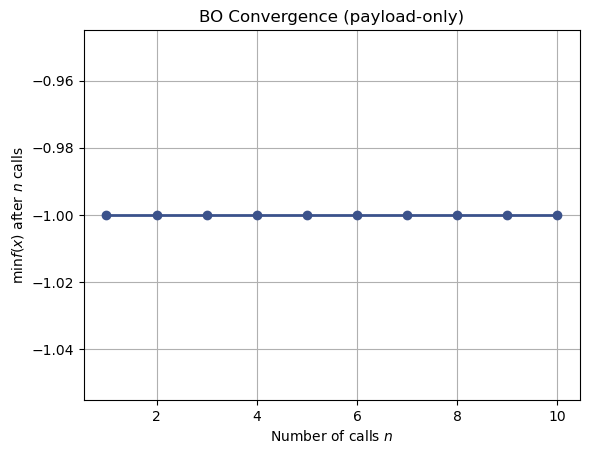

<Figure size 640x480 with 0 Axes>

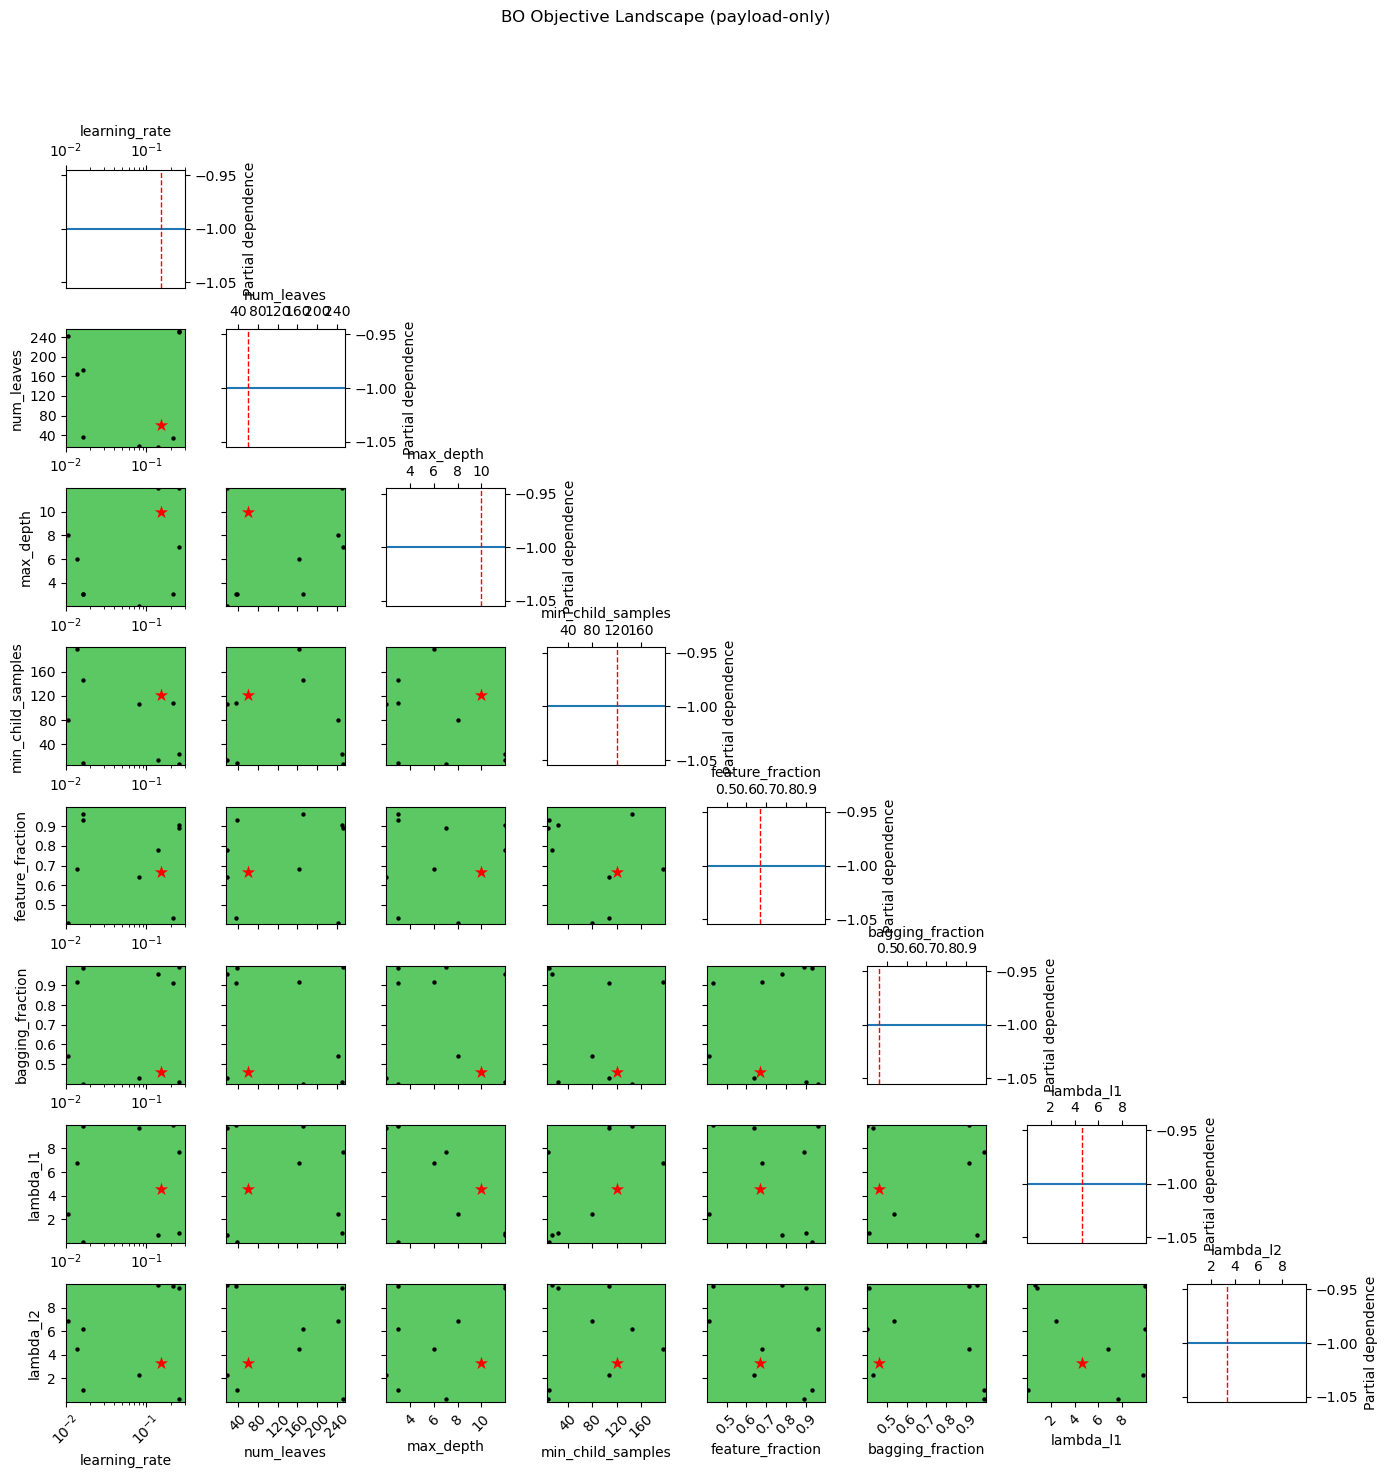

In [10]:
# ======================================================
# Section 4.5 — BO Diagnostics & Visualisations (payload-only)
#   • Summarise trial log; plot convergence/partials if possible
# ======================================================
print(">>> Section 4.5: BO Diagnostics & Visualisations (payload-only)")

import json, math
import pandas as pd
import matplotlib.pyplot as plt

# Load JSONL log into DataFrame
rows = []
if BO_LOG.exists():
    with BO_LOG.open() as f:
        for line in f:
            try:
                rows.append(json.loads(line))
            except Exception:
                pass

if rows:
    df = pd.DataFrame(rows)
    df = df.sort_values("mean_cv_ap", ascending=False)
    print("[4.5] Top 5 trials by CV AP:")
    print(df.head(5).to_string(index=False))
else:
    print("[4.5] No BO log entries found at", BO_LOG)

# Plot convergence if optimiser state exists
if BO_STATE.exists():
    from skopt.plots import plot_convergence, plot_objective
    res = joblib.load(BO_STATE)

    plt.figure()
    plot_convergence(res)
    plt.title("BO Convergence (payload-only)")
    plt.show()

    plt.figure()
    plot_objective(res)
    plt.suptitle("BO Objective Landscape (payload-only)")
    plt.show()
else:
    print("[4.5] No optimiser state to plot; run 4.3 first.")


In [11]:
# --- Persist best tree metric for downstream notebooks ---
from pathlib import Path
import json

metrics_dir = Path("out") / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

# Replace these with your real best scores at the end of 04/06
best_tree_val_acc = float(globals().get("BEST_TREE_VAL_ACC", 0.0))
best_tree_name    = str(globals().get("BEST_TREE_NAME", "unknown"))

payload = {"best_tree_name": best_tree_name, "best_tree_val_acc": best_tree_val_acc}
with open(metrics_dir / "best_tree.json", "w") as f:
    json.dump(payload, f)

print(f"[persist] Wrote best tree → {metrics_dir/'best_tree.json'}: {payload}")


[persist] Wrote best tree → out/metrics/best_tree.json: {'best_tree_name': 'unknown', 'best_tree_val_acc': 0.0}
